# **02_FeatureCorrelations**

Este notebook calcula correlaciones de Pearson de grupos de features por modelo sobre el dataset **match-level** ya consolidado.

Para cada modelo:
- Selecciona columnas definidas en listas editables.
- Calcula correlación con `WL_NUM`.
- Muestra **top-5 por |corr|** y **heatmap** de ese top-5 + `WL_NUM`.

Rutas y grupos están ajustados al parquet final generado por el pipeline.


In [1]:
# Imports y configuración
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PARQUET_PATH = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00d_featurized/00a_WL_prediction/teamgamelogs.parquet"
TARGET = "WL_NUM"
TOP_K =10

## **Carga del parquet y chequeos básicos**

- Lee el parquet consolidado (sin temporada).
- Comprueba que exista `WL_NUM`.
- Nos quedamos con columnas **numéricas** para correlación.


In [2]:
df = pd.read_parquet(PARQUET_PATH)
print(f"Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

if TARGET not in df.columns:
    raise KeyError(f"Falta la columna objetivo '{TARGET}' en el parquet.")

# Duplicadas por nombre
df = df.loc[:, ~df.columns.duplicated()]

# Duplicadas por contenido idéntico
dup_content = df.T.duplicated()
if dup_content.any():
    dup_cols = df.columns[dup_content].tolist()
    df = df.loc[:, ~dup_content]
    print(f"🧹 Quitadas {len(dup_cols)} columnas duplicadas por contenido.")

numeric_df = df.select_dtypes(include=[np.number]).copy()
print(f"Numéricas: {numeric_df.shape[1]}")


Dataset: 1311 filas x 93 columnas
🧹 Quitadas 4 columnas duplicadas por contenido.
Numéricas: 87


## **Listas de columnas por modelo (EDITABLES)**

A continuación se definen listas de columnas por modelo, **ajustadas a tu dataset actual** (todas en forma `DIFF_*` + `P_ELO_HOME`).
Puedes añadir o quitar columnas en cada lista; el notebook filtrará automáticamente las que existan.


In [3]:
FEATURE_GROUPS = {
    # BASELINE: diferenciales de rolling-10 y métricas base (prefijo DIFF_ROLL10_)
    "baseline": [
        "DIFF_ROLL10_PLUS_MINUS",
        "DIFF_ROLL10_OFF_RATING", "DIFF_ROLL10_DEF_RATING", "DIFF_ROLL10_NET_RATING",
        "DIFF_ROLL10_E_OFF_RATING", "DIFF_ROLL10_E_DEF_RATING", "DIFF_ROLL10_E_NET_RATING",
        "DIFF_ROLL10_PACE", "DIFF_ROLL10_E_PACE", "DIFF_ROLL10_PACE_PER40",
        "DIFF_ROLL10_TS_PCT", "DIFF_ROLL10_EFG_PCT",
        "DIFF_ROLL10_USG_PCT",
        "DIFF_ROLL10_FG_PCT", "DIFF_ROLL10_FG3_PCT", "DIFF_ROLL10_FT_PCT",
        "DIFF_ROLL10_FGM", "DIFF_ROLL10_FGA", "DIFF_ROLL10_FG3M", "DIFF_ROLL10_FG3A",
        "DIFF_ROLL10_FTM", "DIFF_ROLL10_FTA",
        "DIFF_ROLL10_REB", "DIFF_ROLL10_OREB", "DIFF_ROLL10_DREB",
        "DIFF_ROLL10_REB_PCT", "DIFF_ROLL10_OREB_PCT", "DIFF_ROLL10_DREB_PCT",
        "DIFF_ROLL10_AST", "DIFF_ROLL10_TOV", "DIFF_ROLL10_TM_TOV_PCT",
        "DIFF_ROLL10_PTS", "DIFF_ROLL10_PIE",
        "DIFF_ROLL10_STL", "DIFF_ROLL10_BLK", "DIFF_ROLL10_BLKA",
        # splits de puntos (si quieres incluirlos en baseline):
        "DIFF_ROLL10_PTS_FB", "DIFF_ROLL10_PTS_OFF_TOV", "DIFF_ROLL10_PTS_PAINT", "DIFF_ROLL10_PTS_2ND_CHANCE",
        "DIFF_ROLL10_OPP_PTS_FB", "DIFF_ROLL10_OPP_PTS_OFF_TOV", "DIFF_ROLL10_OPP_PTS_PAINT", "DIFF_ROLL10_OPP_PTS_2ND_CHANCE",
        # porcentajes de composición (opcionales, ya listados por si quieres probar):
        "DIFF_ROLL10_PCT_PTS", "DIFF_ROLL10_PCT_PTS_2PT", "DIFF_ROLL10_PCT_PTS_3PT", "DIFF_ROLL10_PCT_PTS_FT",
        "DIFF_ROLL10_PCT_PTS_OFF_TOV", "DIFF_ROLL10_PCT_PTS_PAINT", "DIFF_ROLL10_PCT_PTS_FB", "DIFF_ROLL10_PCT_PTS_2PT_MR",
        "DIFF_ROLL10_PCT_AST_FGM", "DIFF_ROLL10_PCT_AST_2PM", "DIFF_ROLL10_PCT_AST_3PM",
        "DIFF_ROLL10_PCT_UAST_FGM", "DIFF_ROLL10_PCT_UAST_2PM", "DIFF_ROLL10_PCT_UAST_3PM",
        "DIFF_ROLL10_PCT_REB", "DIFF_ROLL10_PCT_FGA", "DIFF_ROLL10_PCT_FGM", "DIFF_ROLL10_PCT_FTA", "DIFF_ROLL10_PCT_FTM",
        "DIFF_ROLL10_PCT_DREB", "DIFF_ROLL10_PCT_OREB", "DIFF_ROLL10_PCT_TOV",
        "DIFF_ROLL10_PCT_STL", "DIFF_ROLL10_PCT_PF", "DIFF_ROLL10_PCT_PFD",
        # posesiones
        "DIFF_ROLL10_POSS",
    ],

    # VENUE: diferenciales de win% home/road
    "venue": [
        "DIFF_VENUE_HOME_W_PCT", "DIFF_VENUE_ROAD_W_PCT",
    ],

    # ENHANCED: calendario/forma/tempo (diferenciales)
    "enhanced": [
        "DIFF_DAYS_REST", "DIFF_LAST_5_PCT", "DIFF_WIN_STREAK", "DIFF_SEASON_W_PCT",
        "DIFF_PACE", "DIFF_TURNOVER_RATIO",
    ],

    # ELO: rating dinámico y probabilidad ELO
    "elo": [
        "DIFF_ELO_PRE", "DIFF_ELO_OPP_PRE", "DIFF_ELO_DIFF_PRE", "P_ELO_HOME",
    ],
}

# Puedes editar estas listas cuando añadas nuevas columnas en el pipeline.


## Utilidades
- Selección de columnas válidas
- Correlación con `WL_NUM`
- Etiquetas cortas y heatmap legible


In [4]:
def available_cols(df_num, cols):
    """Filtra las columnas que existen en el dataframe numérico."""
    return [c for c in cols if c in df_num.columns]

def remove_high_corr(df_num, cols, thresh=0.98):
    """Elimina columnas muy correlacionadas entre sí (|ρ| >= thresh)."""
    X = df_num[cols].dropna(axis=0, how="any")
    if X.shape[1] <= 1:
        return cols
    corr = X.corr().abs()
    to_drop = set()
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            a, b = corr.columns[i], corr.columns[j]
            if corr.iloc[i, j] >= thresh and b not in to_drop:
                to_drop.add(b)
    if to_drop:
        print(f"🧹 Eliminadas {len(to_drop)} colineales: {', '.join(list(to_drop)[:6])}{'…' if len(to_drop)>6 else ''}")
    return [c for c in cols if c not in to_drop]

def corr_with_target(df_num, cols, target):
    """Correlaciones con el target."""
    X = df_num[cols + [target]].dropna()
    if X.empty:
        return pd.DataFrame(columns=["feature","corr","abs_corr"])
    out = pd.DataFrame({
        "feature": cols,
        "corr": [X[c].corr(X[target]) for c in cols]
    })
    out["abs_corr"] = out["corr"].abs()
    return out.sort_values("abs_corr", ascending=False)

def _short(s: str) -> str:
    return (s.replace("DIFF_ROLL10_","R10_")
             .replace("DIFF_","D_")
             .replace("_OPP_","_O_")
             .replace("_OFF_","_OF_")
             .replace("_DEF_","_DF_"))

def plot_topk_heatmap(df_num, feats, target):
    cols = feats + [target]
    X = df_num[cols].dropna(axis=0, how="any")
    if X.shape[1] < 2 or X.shape[0] == 0:
        print("⚠️ Heatmap: sin datos suficientes."); return
    corr = X.corr()
    labels = [_short(c) for c in corr.columns]
    n = len(labels)
    fig_w, fig_h = max(5, 1.0*n+2), max(4, 0.9*n+1.5)
    plt.figure(figsize=(fig_w, fig_h))
    ax = sns.heatmap(
        corr, annot=True, fmt=".2f", square=True, cbar=True,
        xticklabels=labels, yticklabels=labels, annot_kws={"size":8}
    )
    ax.tick_params(axis="x", labelrotation=35, labelsize=9)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9)
    ax.set_title("Matriz de correlación (top-7 + WL_NUM)", pad=10)
    plt.tight_layout(); plt.show()


## Ejecución por modelo (con limpieza de colinealidad)
Para cada modelo:
1. Selecciona columnas válidas.
2. Elimina las muy correlacionadas entre sí (ρ≥0.98).
3. Calcula correlación con `WL_NUM`.
4. Muestra top-7 y dibuja heatmap.



=== BASELINE ===
Columnas válidas: 65
🧹 Eliminadas 1 colineales: DIFF_ROLL10_PACE_PER40
                    feature   corr
     DIFF_ROLL10_PLUS_MINUS  0.332
   DIFF_ROLL10_E_NET_RATING  0.283
DIFF_ROLL10_OPP_PTS_OFF_TOV -0.236
            DIFF_ROLL10_PTS  0.221
            DIFF_ROLL10_FGM  0.217
     DIFF_ROLL10_DEF_RATING -0.208
         DIFF_ROLL10_FG_PCT  0.207
            DIFF_ROLL10_TOV -0.205
        DIFF_ROLL10_USG_PCT -0.199
     DIFF_ROLL10_OPP_PTS_FB -0.184


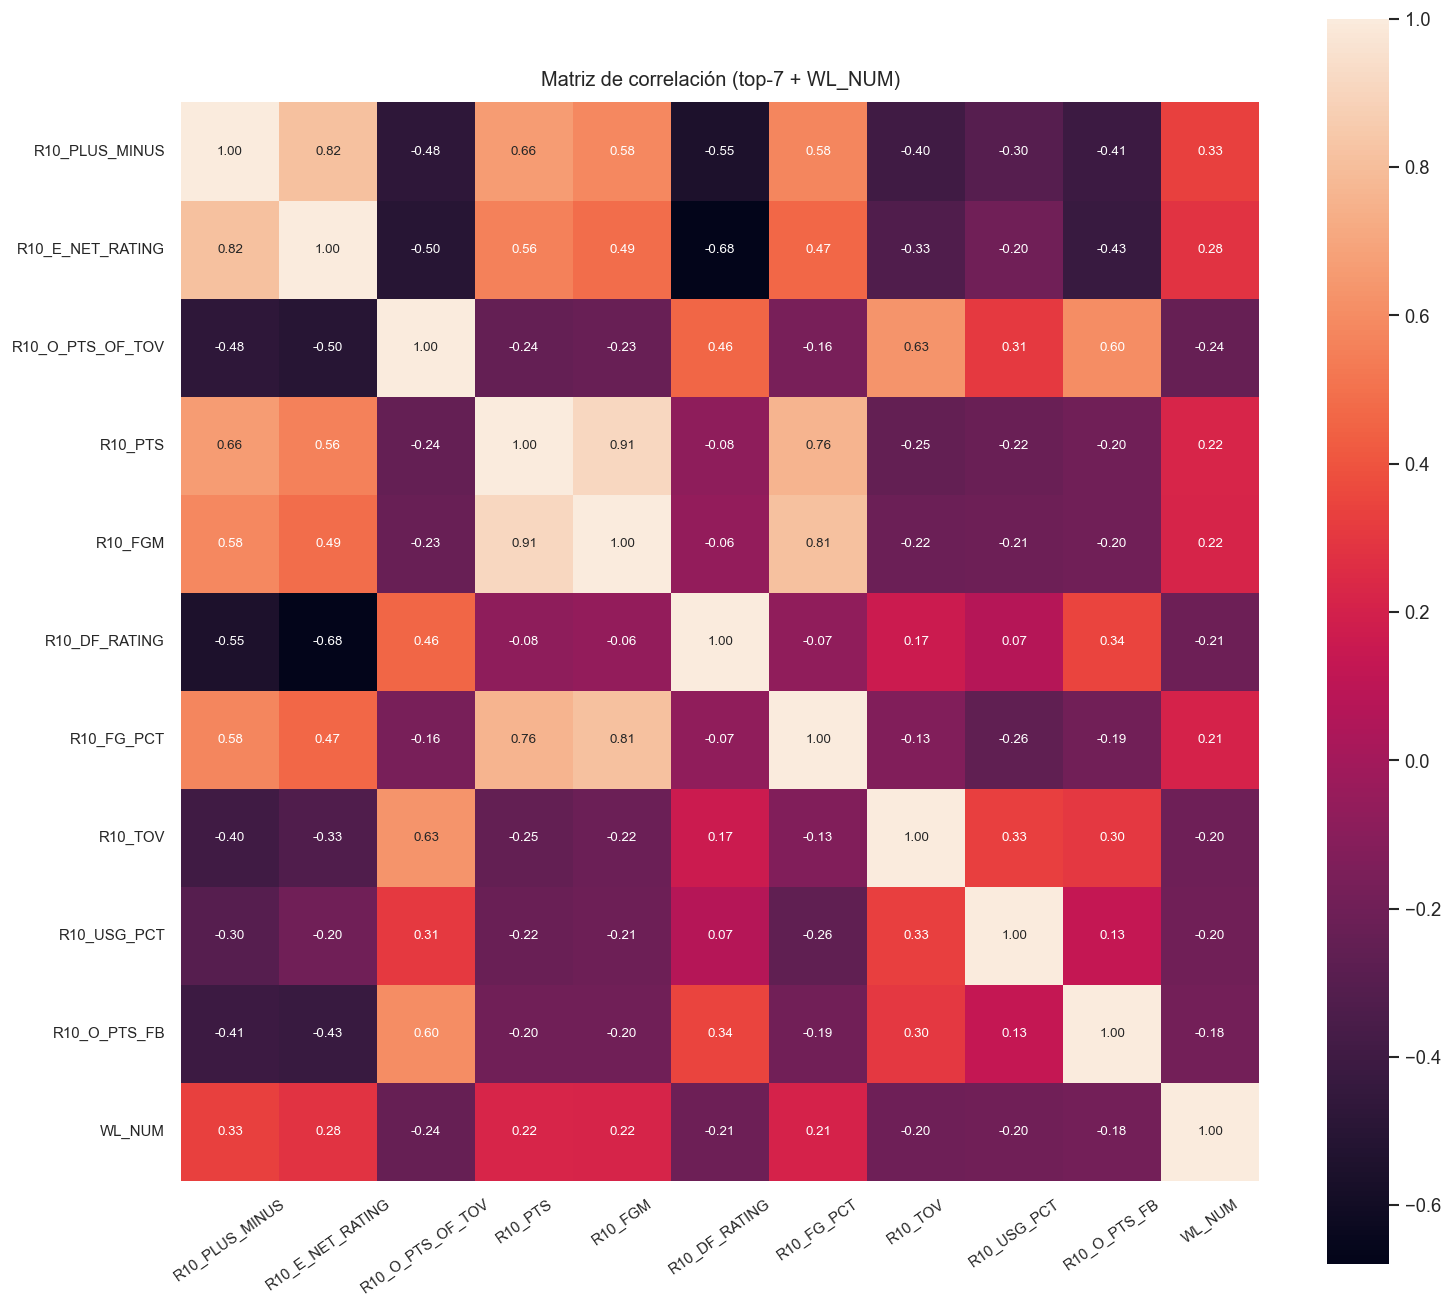


=== VENUE ===
Columnas válidas: 2
              feature  corr
DIFF_VENUE_HOME_W_PCT 0.391
DIFF_VENUE_ROAD_W_PCT 0.387


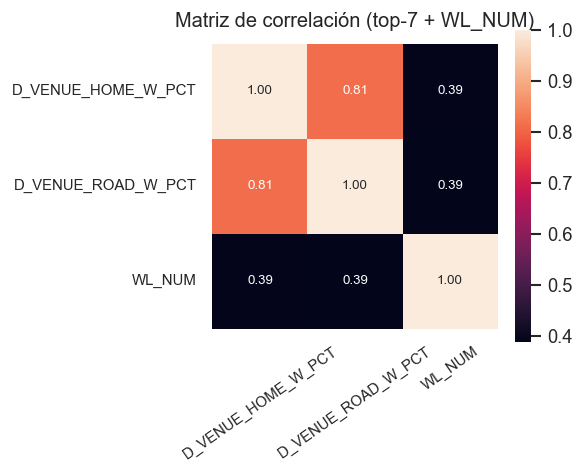


=== ENHANCED ===
Columnas válidas: 6
            feature   corr
  DIFF_SEASON_W_PCT  0.303
    DIFF_LAST_5_PCT  0.260
    DIFF_WIN_STREAK  0.197
DIFF_TURNOVER_RATIO -0.152
          DIFF_PACE  0.117
     DIFF_DAYS_REST  0.056


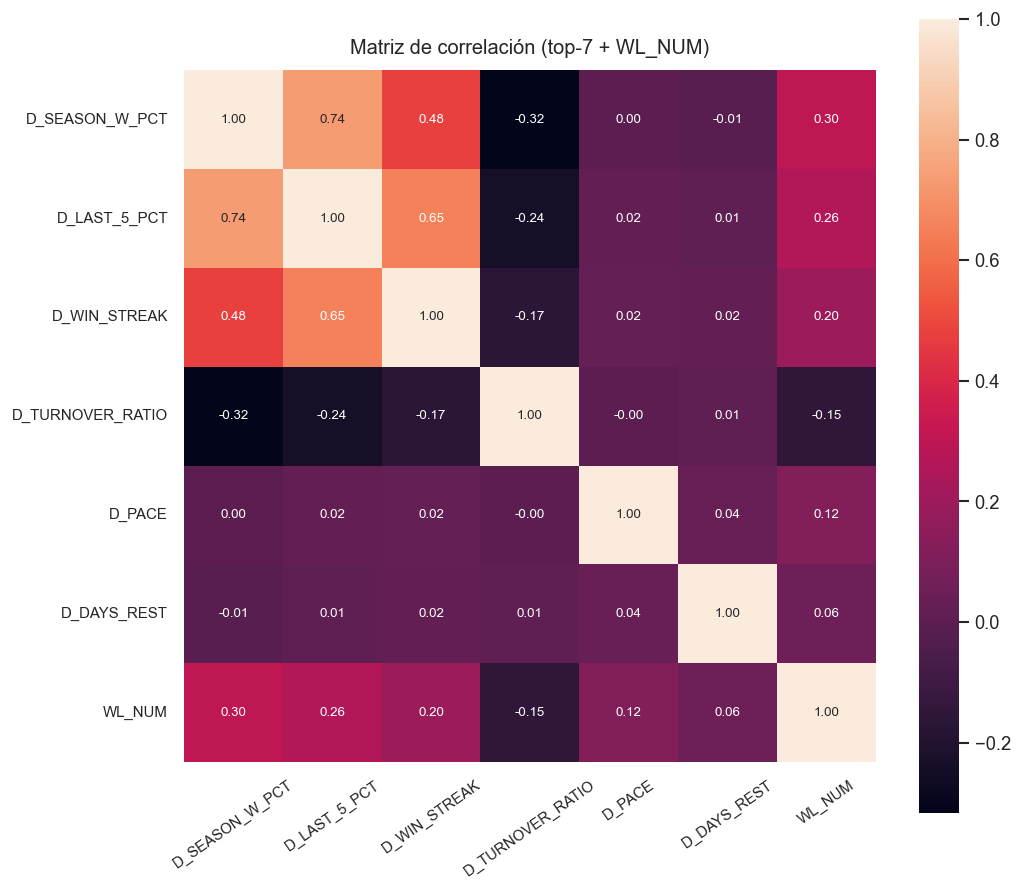


=== ELO ===
Columnas válidas: 4
🧹 Eliminadas 3 colineales: DIFF_ELO_OPP_PRE, DIFF_ELO_DIFF_PRE, P_ELO_HOME
     feature  corr
DIFF_ELO_PRE 0.345


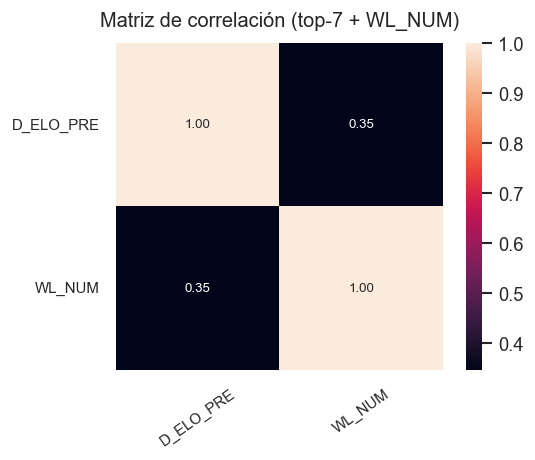

💾 Guardado parquet limpio con features seleccionadas.


In [5]:
for model in ["baseline","venue","enhanced","elo"]:
    print(f"\n=== {model.upper()} ===")
    cols = available_cols(numeric_df, FEATURE_GROUPS.get(model, []))
    print(f"Columnas válidas: {len(cols)}")
    if not cols:
        print("⚠️ Sin columnas válidas; saltando."); continue

    # 🔧 elimina colineales
    cols = remove_high_corr(numeric_df, cols, thresh=0.98)
    if not cols:
        print("⚠️ Todas colineales; saltando."); continue

    df_corr = corr_with_target(numeric_df, cols, TARGET)
    if df_corr.empty:
        print("⚠️ Sin correlaciones; saltando."); continue

    top = df_corr.dropna(subset=["corr"]).head(TOP_K)
    print(top[["feature","corr"]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    plot_topk_heatmap(numeric_df, top["feature"].tolist(), TARGET)

# 💾 Guardar parquet limpio con las features ya depuradas
df.to_parquet(
    "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00d_featurized/00a_WL_prediction/teamgamelogs_cleaned.parquet",
    index=False
)
print("💾 Guardado parquet limpio con features seleccionadas.")


## Resumen rápido por grupo
Para ver cuántas columnas de cada lista existen realmente en el parquet.


In [6]:
summary = []
for m, cols in FEATURE_GROUPS.items():
    present = [c for c in cols if c in numeric_df.columns]
    summary.append({"modelo": m, "presentes": len(present), "faltan": len(cols)-len(present)})
pd.DataFrame(summary).sort_values("modelo").reset_index(drop=True)


,modelo,presentes,faltan
0,baseline,65,5
1,elo,4,0
2,enhanced,6,0
3,venue,2,0
